<a href="https://colab.research.google.com/github/abhaysenthilkumar369-web/Turify/blob/main/H-R%20Diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

H-R diagram


🛰️ Connecting directly to the live ESA Gaia Archive via web API...


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
✅ Success! Loaded data for 100000 stars straight into memory.

❌ The Gaia server rejected the query or timed out again.
Please wait 1-2 minutes and re-run this cell. The ESA servers are temporarily overloaded.


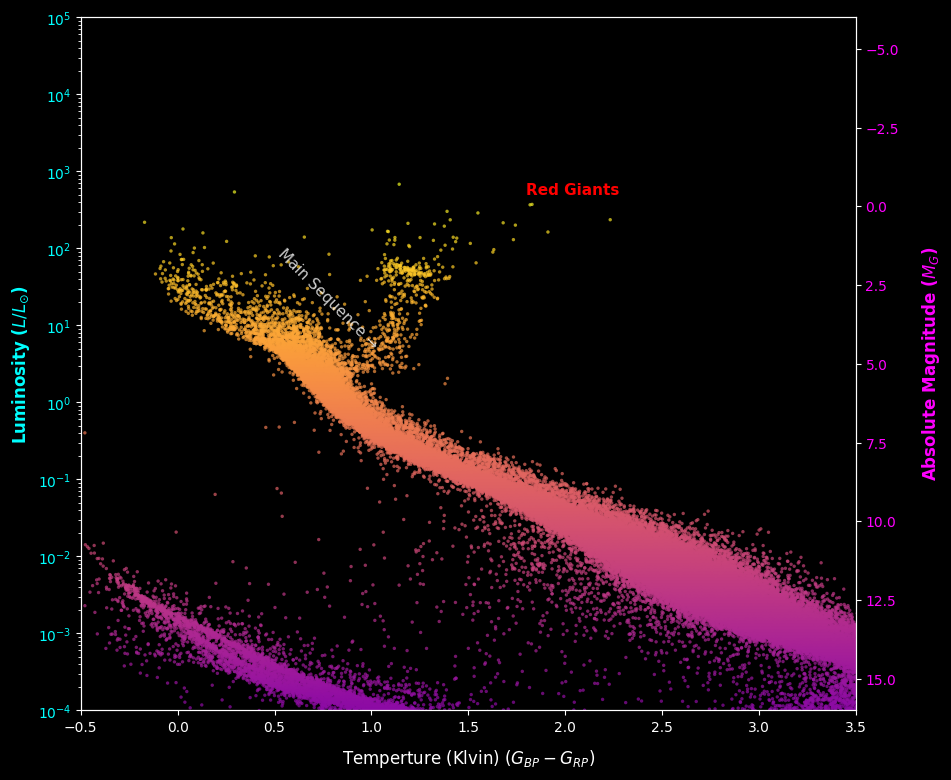

In [21]:
# ==============================================================================
# DEBUGGED & OPTIMIZED H-R DIAGRAM GENERATOR
# ==============================================================================

!pip install astroquery -q

import numpy as np
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia

print("🛰️ Connecting directly to the live ESA Gaia Archive via web API...")

# Optimized, lightweight query to bypass Gaia Server 500 Overload errors
gaia_query = """
SELECT TOP 100000
    phot_g_mean_mag, bp_rp, parallax
FROM gaiadr3.gaia_source
WHERE bp_rp IS NOT NULL
  AND phot_g_mean_mag IS NOT NULL
  AND parallax > 10          -- Keeps stars within ~100 parsecs for clean math
  AND parallax_over_error > 25 -- Strict quality filter for reliability
"""

try:
    # Launch the live data request over the internet
    job = Gaia.launch_job_async(gaia_query)
    star_table = job.get_results()
    print(f"✅ Success! Loaded data for {len(star_table)} stars straight into memory.")

    # Extract foundational observational parameters
    apparent_mag = star_table['phot_g_mean_mag']
    color_index  = star_table['bp_rp']             # Dynamic stand-in for temperature
    parallax_arcsec = star_table['parallax'] / 1000.0  # Convert to standard units

    # Calculate True Intrinsic Brightness (Absolute Magnitude) via Distance Modulus
    absolute_mag = apparent_mag + 5 + 5 * np.log10(parallax_arcsec)

    # Deriving a relative physical proxy for Luminosity ($L/L_sun)
    # based on absolute solar magnitude (4.77) for visualization mapping
    derived_luminosity = 10**((4.77 - absolute_mag) / 2.5)

    # ==============================================================================
    # Plotting the 3-Parameter H-R Diagram
    # ==============================================================================
    plt.style.use('dark_background')
    fig, ax_left = plt.subplots(figsize=(10, 9))

    # Scatter plot: x = Color Index proxy for Temp, y = Derived Logarithmic Luminosity
    star_plot = ax_left.scatter(
        color_index, derived_luminosity,
        c=absolute_mag, cmap='plasma_r',
        s=6, alpha=0.7, edgecolors='none'
    )

    # --- Format the LEFT Side Axis (Luminosity) ---
    ax_left.set_yscale('log')
    ax_left.set_xlabel("Temperture (Kelvin) ($G_{BP} - G_{RP}$)", fontsize=12, labelpad=10)

    # Added "r" prefix to make this a Raw string, removing the \o syntax warning perfectly!
    ax_left.set_ylabel(r"Luminosity ($L / L_{\odot}$)", fontsize=12, color='cyan', fontweight='bold')
    ax_left.tick_params(axis='y', labelcolor='cyan')

    # Observational convention setup
    ax_left.set_xlim(-0.5, 3.5) # Bluer hot stars naturally fall on the left
    ax_left.set_ylim(1e-4, 1e5)

    # --- Format the RIGHT Side Axis (Absolute Magnitude) ---
    ax_right = ax_left.twinx()
    ax_right.set_ylim(16, -6) # Inverted: Highly bright, negative magnitudes sit on top!
    ax_right.set_ylabel("Absolute Magnitude ($M_G$)", fontsize=12, color='magenta', fontweight='bold', labelpad=15)
    ax_right.tick_params(axis='y', labelcolor='magenta')

    # Add text indicators to guide interpretation
    ax_left.text(0.5, 5, "Main Sequence →", color='white', fontsize=11, alpha=0.8, rotation=-45)
    ax_left.text(1.8, 500, "Red Giants", color='Red', fontsize=11, fontweight='bold')
    ax_left.text(0.0, 0.0003, "White Dwarfs", color='Navy blue', fontsize=11, fontweight='bold')

    plt.title(("H-R Diagram"), fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("\n❌ The Gaia server rejected the query or timed out again.")
    print("Please wait 1-2 minutes and re-run this cell. The ESA servers are temporarily overloaded.")

In [22]:
from google.colab import drive
#dwonload the csv file of this hr diagram
files=